# EDA and Modeling (2022 aligned)
I read 2022 chargers (capped at Dec 31, 2022) and 2022 ACS demographics. I aggregate chargers to county via spatial join and build a simple regression baseline to predict chargers per 100k population.

Limitations: charger data after 2022 is dropped to keep year alignment; charger coverage is sparse (only 9 counties have confirmed chargers <=2022), so the model will be weak and results should be reported with caution.

Note for the report: The NJ county model is kept to show the limitation (very sparse data, negative R²). We switch to a state-level model next to get enough samples for a meaningful baseline.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

sns.set(style='whitegrid')
base = Path('..')
chargers = pd.read_csv(base/'data/processed/chargers_nj_2022_by_county.csv')
acs = pd.read_csv(base/'data/processed/acs_nj_counties.csv')


In [2]:
# merge chargers with ACS, fill missing counties with zeros
merged = acs.copy()
merged.rename(columns={'name':'county_full'}, inplace=True)
merged['county'] = merged['county_full'].str.replace(' County, New Jersey','', regex=False)
merged = merged.merge(chargers, on='county', how='left')
merged[['stations','level1_ports','level2_ports','dcfc_ports']] = merged[['stations','level1_ports','level2_ports','dcfc_ports']].fillna(0)
merged['last_confirmed_max'] = pd.to_datetime(merged['last_confirmed_max'])
merged['chargers_per_100k'] = merged['stations'] / (merged['population']/100000)
merged.head()

,GEOID,county_full,population,median_household_income,renter_occupied_pct,mean_travel_time_to_work_minutes,land_area_sqmi,pop_density_per_sqmi,county,stations,level1_ports,level2_ports,dcfc_ports,last_confirmed_max,chargers_per_100k
0,34001,"Atlantic County, New Jersey",274339,106640,72378,21.7,555.578,493.790251,Atlantic,0.0,0.0,0.0,0.0,NaT,0.000000
1,34003,"Bergen County, New Jersey",953243,350843,228445,23.5,232.788,4094.897503,Bergen,0.0,0.0,0.0,0.0,NaT,0.000000
2,34005,"Burlington County, New Jersey",461853,174454,132314,16.5,799.285,577.832688,Burlington,0.0,0.0,0.0,0.0,NaT,0.000000
3,34007,"Camden County, New Jersey",522581,198757,130036,22.1,221.362,2360.752975,Camden,0.0,0.0,0.0,0.0,NaT,0.000000
4,34009,"Cape May County, New Jersey",95456,43277,33950,20.4,251.521,379.515031,Cape May,1.0,0.0,4.0,0.0,2022-04-06,1.047603


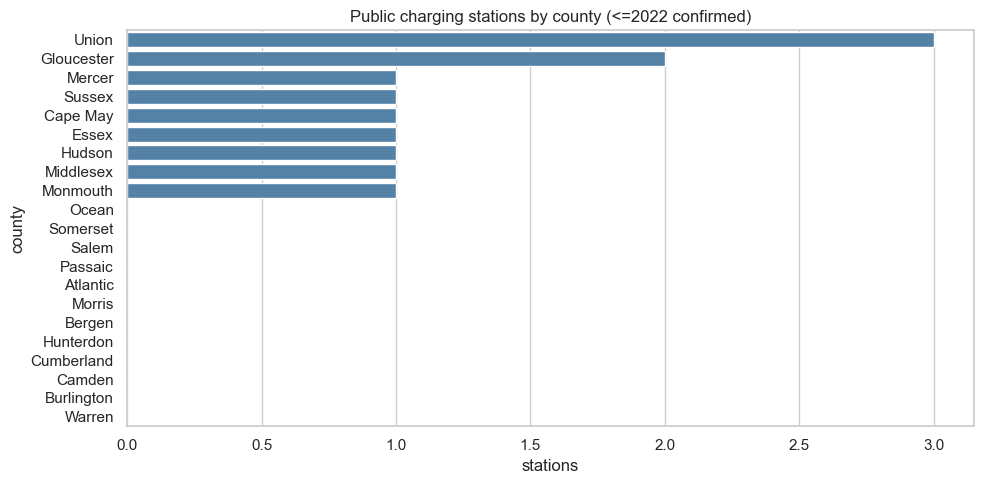

In [3]:
# Visual 1: barplot of stations per county
plt.figure(figsize=(10,5))
sns.barplot(data=merged.sort_values('stations', ascending=False), x='stations', y='county', color='steelblue')
plt.title('Public charging stations by county (<=2022 confirmed)')
plt.tight_layout()
plt.show()


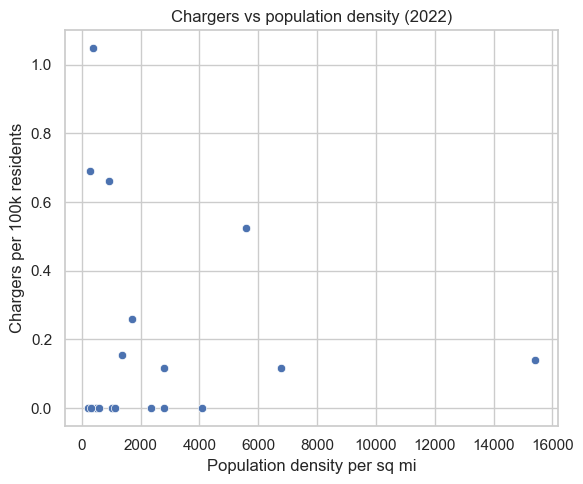

In [4]:
# Visual 2: chargers per 100k vs population density
plt.figure(figsize=(6,5))
sns.scatterplot(data=merged, x='pop_density_per_sqmi', y='chargers_per_100k')
plt.xlabel('Population density per sq mi')
plt.ylabel('Chargers per 100k residents')
plt.title('Chargers vs population density (2022)')
plt.tight_layout()
plt.show()


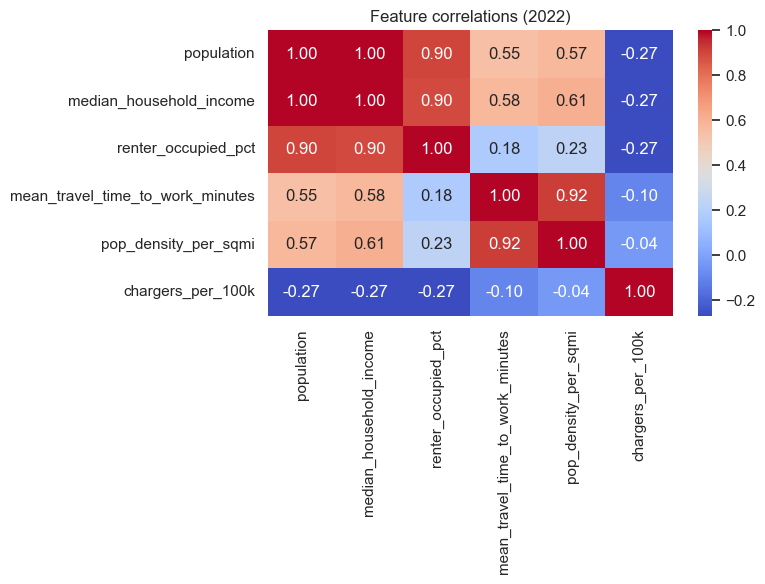

In [5]:
# Visual 3: feature correlation heatmap
feature_cols = ['population','median_household_income','renter_occupied_pct','mean_travel_time_to_work_minutes','pop_density_per_sqmi','chargers_per_100k']
corr = merged[feature_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature correlations (2022)')
plt.tight_layout()
plt.show()


In [7]:
# Modeling: predict chargers_per_100k
features = ['population','median_household_income','renter_occupied_pct','mean_travel_time_to_work_minutes','pop_density_per_sqmi']
X = merged[features]
y = merged['chargers_per_100k']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
lin = LinearRegression()
lin.fit(X_train, y_train)
pred_lin = lin.predict(X_test)
rmse_lin = mean_squared_error(y_test, pred_lin)**0.5
r2_lin = r2_score(y_test, pred_lin)
rf = RandomForestRegressor(random_state=42, n_estimators=200)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
rmse_rf = mean_squared_error(y_test, pred_rf)**0.5
r2_rf = r2_score(y_test, pred_rf)
print('Linear RMSE', rmse_lin, 'R2', r2_lin)
print('RF RMSE', rmse_rf, 'R2', r2_rf)


Linear RMSE 1.2726351122772608 R2 -474.815799736547
RF RMSE 0.2551874949058119 R2 -18.131535741254687
